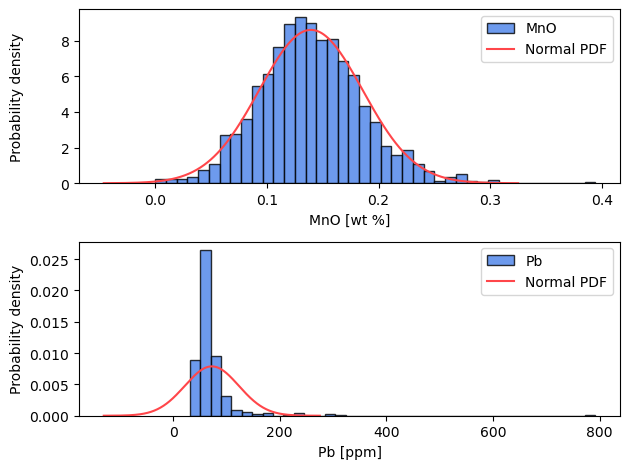

In [ ]:
import pandas as pd  # Mengimpor library pandas untuk manipulasi data 
import matplotlib.pyplot as plt  # Mengimpor library matplotlib untuk visualisasi grafik
from scipy.stats import norm  # Mengimpor distribusi normal dari scipy 
import numpy as np  # Mengimpor library numpy untuk perhitungan numerik

my_dataset_majors = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_majors')  
# Membaca sheet 'Supp_majors' dari file Excel ke DataFrame pandas

my_dataset_traces = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')  
# Membaca sheet 'Supp_traces' dari file Excel ke DataFrame pandas

fig = plt.figure()  # Membuat sebuah figure kosong untuk menampung subplot

# MnO
MnO = my_dataset_majors.MnO  # Mengambil kolom 'MnO' dari DataFrame my_dataset_majors

ax1 = fig.add_subplot(2, 1, 1)  
# Menambahkan subplot pertama (dari 2 baris, 1 kolom, posisi 1) di figure

ax1.hist(MnO, bins='auto', density=True, color='#4881e9', edgecolor='k', label='MnO', alpha=0.8)  
# Membuat histogram MnO, bins otomatis, di-normalisasi ke density, warna biru, tepi hitam, label 'MnO', transparansi 0.8

a_mean = MnO.mean()  # Menghitung rata-rata (mean) dari data MnO
std_dev = MnO.std()  # Menghitung standar deviasi dari data MnO

x = np.linspace(a_mean-4*std_dev, a_mean+4*std_dev,1000)  
# Membuat 1000 titik x dari mean-4*std hingga mean+4*std untuk plot PDF normal

pdf = norm.pdf(x, loc=a_mean, scale=std_dev)  
# Menghitung nilai PDF normal dengan mean dan std yang dihitung dari data MnO

ax1.plot(x, pdf, linewidth=1.5, color='#ff464a',label='Normal PDF')  
# Mem-plot kurva PDF normal di histogram, warna merah, label 'Normal PDF'

ax1.set_xlabel('MnO [wt %]')  # Memberi label sumbu X
ax1.set_ylabel('Probability density')  # Memberi label sumbu Y
ax1.legend()  # Menampilkan legend

#Pb
Pb = my_dataset_traces.Pb  # Mengambil kolom 'Pb' dari DataFrame my_dataset_traces
Pb = Pb.dropna(how='any')  # Menghapus data NaN agar tidak mempengaruhi histogram

ax2 = fig.add_subplot(2, 1, 2)  
# Menambahkan subplot kedua (dari 2 baris, 1 kolom, posisi 2) di figure

ax2.hist(Pb, bins='auto', density=True, color='#4881e9', edgecolor='k', label='Pb', alpha=0.8)  
# Membuat histogram Pb, bins otomatis, di-normalisasi ke density, warna biru, tepi hitam, label 'Pb', transparansi 0.8

a_mean = Pb.mean()  # Menghitung rata-rata (mean) dari data Pb
std_dev = Pb.std()  # Menghitung standar deviasi dari data Pb

x = np.linspace(a_mean-4*std_dev, a_mean+4*std_dev,1000)  
# Membuat 1000 titik x dari mean-4*std hingga mean+4*std untuk plot PDF normal

pdf = norm.pdf(x, loc=a_mean, scale=std_dev)  
# Menghitung nilai PDF normal dengan mean dan std yang dihitung dari data Pb

ax2.plot(x, pdf, linewidth=1.5, color='#ff464a', label='Normal PDF')  
# Mem-plot kurva PDF normal di histogram Pb, warna merah, label 'Normal PDF'

ax2.set_xlabel('Pb [ppm]')  # Memberi label sumbu X
ax2.set_ylabel('Probability density')  # Memberi label sumbu Y
ax2.legend()  # Menampilkan legend

fig.align_ylabels()  
# Menyelaraskan label sumbu Y antara subplot agar sejajar
fig.tight_layout()  
# Menyesuaikan layout secara otomatis agar subplot tidak saling menumpuk

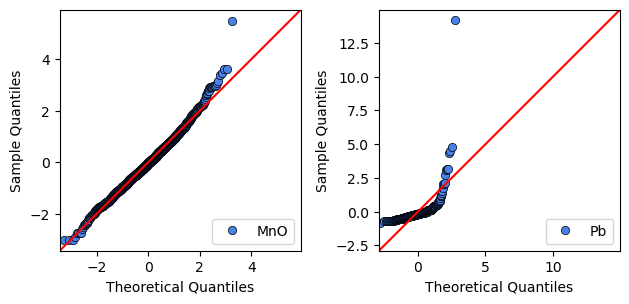

In [ ]:
import statsmodels.api as sm  # Mengimpor library statsmodels untuk analisis statistik, termasuk Q-Q plot

fig = plt.figure()  # Membuat figure kosong baru untuk menampung subplot

ax1 = fig.add_subplot(1, 2, 1)  
# Menambahkan subplot pertama (1 baris, 2 kolom, posisi 1) untuk Q-Q plot MnO

sm.qqplot(data=MnO, fit=True, line="45", ax=ax1, markerfacecolor='#4881e9', 
          markeredgewidth=0.5, markeredgecolor='k', label='MnO')  
# Membuat Q-Q plot data MnO: 
# - fit=True menyesuaikan data dengan distribusi normal
# - line="45" menambahkan garis referensi 45° untuk normalitas
# - ax=ax1 menempatkan plot di subplot pertama
# - markerfacecolor, markeredgewidth, markeredgecolor mengatur warna dan tepi titik
# - label untuk legend

ax1.set_aspect('equal', 'box')  
# Mengatur aspek rasio subplot agar sumbu X dan Y memiliki skala yang sama (kotak sempurna)

ax1.legend(loc='lower right')  
# Menampilkan legenda di pojok kanan bawah subplot pertama

ax2 = fig.add_subplot(1, 2, 2)  
# Menambahkan subplot kedua (1 baris, 2 kolom, posisi 2) untuk Q-Q plot Pb

sm.qqplot(data=Pb, fit=True, line="45", ax=ax2, markerfacecolor='#4881e9', 
          markeredgewidth=0.5, markeredgecolor='k', label='Pb')  
# Membuat Q-Q plot data Pb dengan parameter yang sama seperti MnO

ax2.set_aspect('equal', 'box')  
# Mengatur aspek rasio subplot kedua agar sumbu X dan Y memiliki skala yang sama

ax2.legend(loc='lower right')  
# Menampilkan legenda di pojok kanan bawah subplot kedua

fig.tight_layout()  
# Menyesuaikan layout otomatis agar subplot tidak saling tumpang tindih

In [ ]:
def returns_normal_tests(my_data):  # Mendefinisikan fungsi untuk menguji normalitas pada data input

    from scipy.stats import shapiro, anderson, normaltest  
    # Mengimpor 3 uji statistik normalitas: Shapiro-Wilk, Anderson-Darling, D’Agostino-Pearson

    print('---------------------------------------------')  # Cetak garis pemisah
    print('')  # Cetak baris kosong

    stat, p = shapiro(my_data)  # Jalankan uji Shapiro-Wilk, kembalikan statistik uji dan p-value
    alpha = 0.05  # Tentukan tingkat signifikansi 5%
    if p > alpha:  # Jika p-value > 0.05, gagal menolak H0 (data normal)
        print('Shapiro test fails to reject H0: looks normal :)')
    else:  # Jika p-value <= 0.05, tolak H0 (data tidak normal)
        print('Shapiro test rejects H0: not normal :(')
    print('')  # Baris kosong

    stat, p = normaltest(my_data)  # Jalankan uji D’Agostino-Pearson untuk normalitas
    alpha = 0.05  # Tingkat signifikansi tetap 5%
    if p > alpha:  # Gagal menolak H0 → data terlihat normal
        print("Agostino and Pearson's test fails to reject H0: looks normal")
    else:  # Tolak H0 → data tidak normal
        print("Agostino and Pearson's test rejects H0: not normal")
    print('')  # Baris kosong

    result = anderson(my_data)  # Jalankan uji Anderson-Darling, mengembalikan object dengan statistik dan critical values
    print('Anderson-Darling test:')  # Cetak judul uji
    for sl, cv in zip(result.significance_level, result.critical_values):  
        # Loop untuk tiap tingkat signifikansi (significance level) dan nilai kritis
        if result.statistic < cv:  # Jika statistik uji < nilai kritis → gagal menolak H0 (normal)
            print('%.3f: fails to reject H0: Sample looks normal' % (sl))
        else:  # Statistik uji ≥ nilai kritis → tolak H0 (tidak normal)
            print('%.3f: rejects H0: Sample does not look normal' % (sl))
    print('---------------------------------------------')  # Cetak garis pemisah
    print('')  # Baris kosong


# Original MnO sample
print('Original MnO sample')  # Menampilkan informasi bahwa ini uji pada seluruh sampel MnO
returns_normal_tests(MnO)  # Memanggil fungsi normality test pada data MnO asli

# Removing the outliers above 0.27 wt %
print('MnO sample without observations above 0.27 wt %')  # Informasi bahwa outlier dihapus
MnO_no_outliers = MnO[MnO < 0.27]  # Membuat subset MnO tanpa nilai > 0.27 wt %
returns_normal_tests(MnO_no_outliers)  # Memanggil fungsi normality test pada data tanpa outlier

Original MnO sample
---------------------------------------------

Shapiro test rejects H0: not normal :(

D%*	extcolor{codered}{$	extquotesingle$}*)Agostino and Pearson%*	extcolor{codered}{$	extquotesingle$}*)s test rejects H0: not normal

Anderson-Darling test:
15.000: rejects H0: Sample does not look normal
10.000: rejects H0: Sample does not look normal
5.000: rejects H0: Sample does not look normal
2.500: rejects H0: Sample does not look normal
1.000: rejects H0: Sample does not look normal
---------------------------------------------

MnO sample without observations above 0.27 wt %
---------------------------------------------

Shapiro test fails to reject H0: looks normal :)

D%*	extcolor{codered}{$	extquotesingle$}*)Agostino and Pearson%*	extcolor{codered}{$	extquotesingle$}*)s test fails to reject H0: looks normal

Anderson-Darling test:
15.000: fails to reject H0: Sample looks normal
10.000: fails to reject H0: Sample looks normal
5.000: fails to reject H0: Sample looks norm

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18188\4275990344.py:21: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(my_data)


' Results:\nOriginal MnO sample\n---------------------------------------------\n\nShapiro test rejects H0: not normal\n\nD%*\textcolor{codegreen}{$\textquotesingle$}*)Agostino and Pearson%*\textcolor{codegreen}{$\textquotesingle$}*)s test rejects H0: not normal\n\nAnderson-Darling test:\n15.000: rejects H0: Sample does not look normal\n10.000: rejects H0: Sample does not look normal\n5.000: rejects H0: Sample does not look normal\n2.500: rejects H0: Sample does not look normal\n1.000: rejects H0: Sample does not look normal\n---------------------------------------------\n\nMnO sample without observations above 0.27 wt %\n---------------------------------------------\n\nShapiro test fails to reject H0: looks normal\n\nD%*\textcolor{codegreen}{$\textquotesingle$}*)Agostino and Pearson%*\textcolor{codegreen}{$\textquotesingle$}*)s test fails to reject H0: looks normal\n\nAnderson-Darling test:\n15.000: fails to reject H0: Sample looks normal\n10.000: fails to reject H0: Sample looks norma

Text(106.24270777474374, 0.03, 'Deviation of the arithmetic\nmean from the median: 21.2 %')

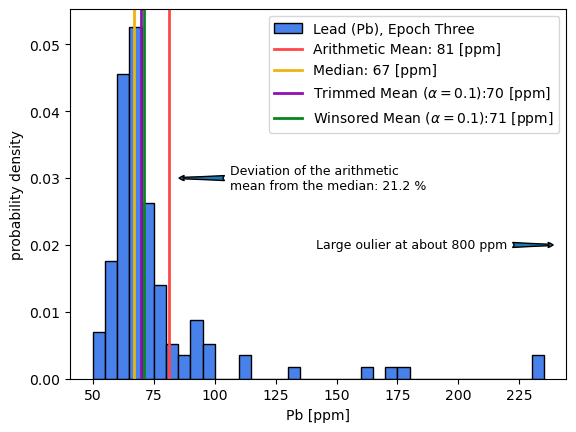

In [ ]:
import pandas as pd  # Mengimpor pandas untuk membaca dan mengolah data
import numpy as np  # Mengimpor numpy untuk operasi numerik
from scipy.stats.mstats import winsorize  # Mengimpor fungsi winsorize (mengurangi efek outlier)
from scipy.stats import trim_mean  # Mengimpor fungsi trimmed mean (mean tanpa sebagian data ekstrem)
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk visualisasi

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name=1)  
# Membaca sheet ke-2 (index 1) dari file Excel ke DataFrame

el = 'Pb'  # Menentukan elemen yang akan dianalisis (Pb = Lead)
my_sub_dataset = my_dataset[my_dataset.Epoch == 'three-b']  
# Memfilter data hanya untuk baris dengan kategori Epoch = 'three-b'

my_sub_dataset = my_sub_dataset.dropna(subset=[el])  
# Menghapus baris yang memiliki nilai NaN pada kolom Pb

fig, ax = plt.subplots()  
# Membuat figure dan axis untuk plotting

a_mean = my_sub_dataset[el].mean()  
# Menghitung rata-rata aritmatika (mean) dari Pb

median = my_sub_dataset[el].median()  
# Menghitung median dari Pb

trimmed_mean = trim_mean(my_sub_dataset[el], proportiontocut=0.1)  
# Menghitung trimmed mean dengan membuang 10% data terendah dan tertinggi

winsorized_mean = np.mean(winsorize(my_sub_dataset[el], limits=0.1))  
# Menghitung winsorized mean: mengganti 10% nilai ekstrem dengan batas terdekat lalu dihitung mean

delta = 100 * (a_mean - median) / median  
# Menghitung persentase deviasi antara mean dan median

bins = np.arange(50, 240, 5)  
# Membuat interval histogram dari 50 sampai 240 dengan lebar bin 5

ax.hist(my_sub_dataset[el], density=True, edgecolor='k', color='#4881e9', bins=bins, label='Lead (Pb), Epoch Three')  
# Membuat histogram Pb, dinormalisasi ke density, warna biru, tepi hitam

ax.axvline(a_mean, color='#ff464a', linewidth=2, label='Arithmetic Mean: {:.0f} [ppm]'.format(a_mean))  
# Menambahkan garis vertikal untuk mean (warna merah)

ax.axvline(median, color='#ebb60d', linewidth=2, label='Median: {:.0f} [ppm]'.format(median))  
# Menambahkan garis vertikal untuk median (warna kuning)

ax.axvline(trimmed_mean, color='#8f10b3', linewidth=2, 
           label=r'Trimmed Mean ($\alpha = 0.1$):' + '{:.0f} [ppm]'.format(trimmed_mean))  
# Menambahkan garis vertikal untuk trimmed mean (warna ungu)

ax.axvline(winsorized_mean, color='#07851e', linewidth=2, 
           label=r'Winsored Mean ($\alpha = 0.1$):' + '{:.0f} [ppm]'.format(winsorized_mean))  
# Menambahkan garis vertikal untuk winsorized mean (warna hijau)

ax.set_xlabel(el + " [ppm]")  
# Memberi label sumbu X (Pb dalam ppm)

ax.set_ylabel('probability density')  
# Memberi label sumbu Y

ax.legend()  
# Menampilkan legenda

ax.annotate('Large oulier at about 800 ppm', (240, 0.02), (220, 0.02), 
            ha="right", va="center", size=9, arrowprops=dict(arrowstyle='fancy'))  
# Menambahkan anotasi teks dengan panah yang menunjukkan adanya outlier besar (~800 ppm)

ax.annotate('Deviation of the arithmetic\nmean from the median: {:.1f} %'.format(delta), 
            (a_mean + 3, 0.03), (a_mean + 25, 0.03), 
            ha="left", va="center", size=9, arrowprops=dict(arrowstyle='fancy'))  
# Menambahkan anotasi deviasi antara mean dan median dalam persen, dengan panah

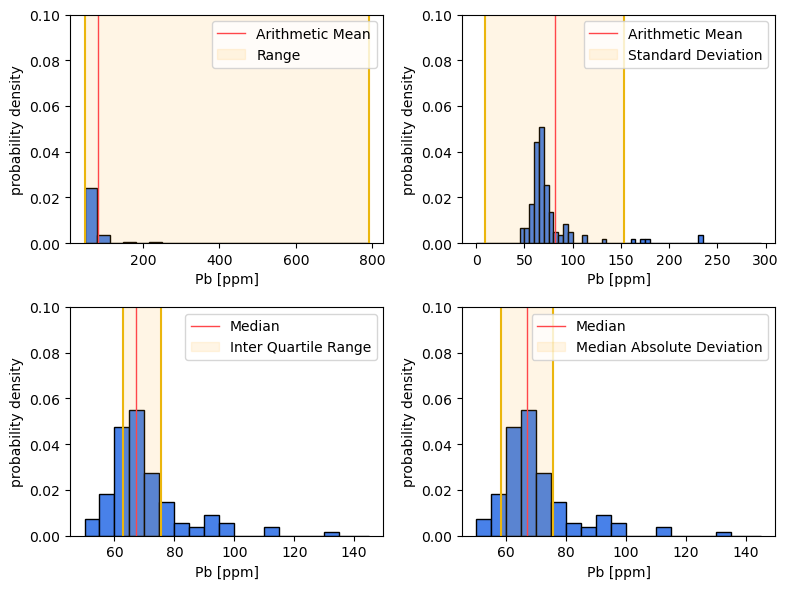

In [ ]:
import pandas as pd  # Mengimpor pandas untuk membaca dan mengolah data
import numpy as np  # Mengimpor numpy untuk operasi numerik
from scipy import stats  # Mengimpor modul statistik dari scipy
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk visualisasi

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name=1)  
# Membaca sheet ke-2 dari file Excel ke dalam DataFrame

el = 'Pb'  # Menentukan kolom yang dianalisis (Pb = Lead)

my_sub_dataset = my_dataset[my_dataset.Epoch == 'three-b']  
# Memfilter data hanya untuk Epoch 'three-b'

my_sub_dataset = my_sub_dataset.dropna(subset=[el])  
# Menghapus baris yang memiliki nilai kosong (NaN) pada kolom Pb

a_mean = my_sub_dataset[el].mean()  
# Menghitung mean (rata-rata aritmatika)

median = my_sub_dataset[el].median()  
# Menghitung median

range_values = [my_sub_dataset[el].min(), my_sub_dataset[el].max()]  
# Mengambil nilai minimum dan maksimum (Range)

std_dev_values = [a_mean - my_sub_dataset[el].std(), a_mean + my_sub_dataset[el].std()]  
# Menghitung batas bawah & atas berdasarkan mean ± standar deviasi

IQR_values = [np.percentile(my_sub_dataset[el], 25, method='midpoint'), 
              np.percentile(my_sub_dataset[el], 75, method='midpoint')]  
# Menghitung kuartil 1 (Q1) dan kuartil 3 (Q3) untuk Interquartile Range (IQR)

MADn_values = [median - stats.median_abs_deviation(my_sub_dataset[el], scale='normal'), 
               median + stats.median_abs_deviation(my_sub_dataset[el], scale='normal')]  
# Menghitung Median Absolute Deviation (MAD), diskalakan ke distribusi normal

scales_values = [range_values, std_dev_values, IQR_values, MADn_values]  
# Menggabungkan semua ukuran penyebaran ke dalam list

scale_labels = ['Range', 'Standard Deviation', 'Inter Quartile Range', 'Median Absolute Deviation']  
# Label untuk masing-masing ukuran penyebaran

locations = [a_mean, a_mean, median, median]  
# Titik pusat (mean atau median) untuk tiap metode

location_labels = ['Arithmetic Mean', 'Arithmetic Mean', 'Median', 'Median']  
# Label titik pusat

binnings = ['auto', np.arange(0,300,5), np.arange(50,150,5), np.arange(50,150,5)]  
# Pengaturan bin histogram yang berbeda untuk tiap subplot

indexes = [1, 2, 3, 4]  
# Posisi subplot dalam grid 2x2

fig = plt.figure(figsize=(8,6))  
# Membuat figure dengan ukuran 8x6 inci

for scale_values, location, scale_label, location_label, bins, index in zip(scales_values, locations, scale_labels, location_labels, binnings, indexes):  
    # Loop untuk membuat 4 subplot berdasarkan masing-masing ukuran penyebaran

    ax = fig.add_subplot(2, 2, index)  
    # Membuat subplot dalam grid 2x2 sesuai index

    ax.hist(my_sub_dataset[el], density=True, edgecolor='k', color='#4881e9', bins=bins)  
    # Membuat histogram data Pb

    ax.axvline(location, color='#ff464a', linewidth=1, label=location_label)  
    # Garis vertikal untuk mean atau median

    ax.axvline(scale_values[0], color='#ebb60d')  
    # Garis batas bawah dari ukuran penyebaran

    ax.axvline(scale_values[1], color='#ebb60d')  
    # Garis batas atas dari ukuran penyebaran

    ax.axvspan(scale_values[0], scale_values[1], alpha=0.1, color='orange', label=scale_label)  
    # Area diarsir antara batas bawah & atas (visualisasi penyebaran)

    ax.set_xlabel(el + " [ppm]")  
    # Label sumbu X

    ax.set_ylabel('probability density')  
    # Label sumbu Y

    ax.set_ylim(0, 0.1)  
    # Mengatur batas sumbu Y agar konsisten antar subplot

    ax.legend(loc='upper right')  
    # Menampilkan legenda di kanan atas

fig.tight_layout()  
# Menyesuaikan layout agar subplot tidak saling tumpang tindih

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18188\307767676.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax.axvline(h_loc, color = '#ff464a', linewidth = 2, label= loc_label + " as $\psi$: location at {:.1f} [ppm]".format(h_loc))


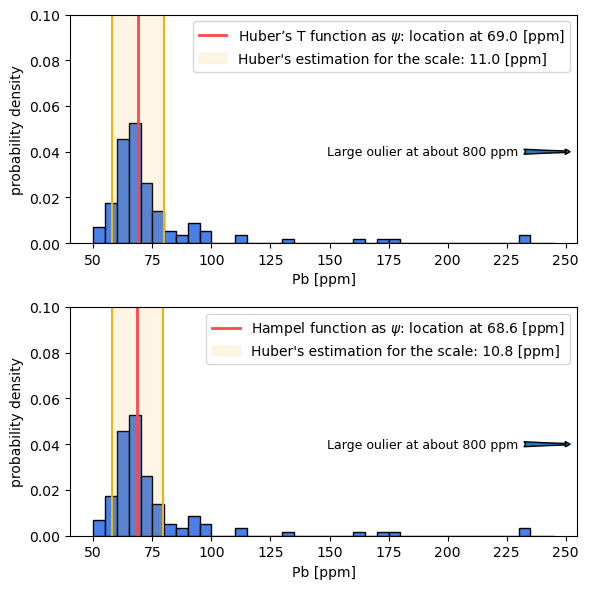

In [ ]:
import pandas as pd  # Mengimpor pandas untuk membaca dan mengolah data
import numpy as np  # Mengimpor numpy untuk operasi numerik
import statsmodels.api as st  # Mengimpor statsmodels untuk analisis statistik robust
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk visualisasi

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name=1)  
# Membaca sheet ke-2 dari file Excel

el = 'Pb'  # Menentukan variabel yang dianalisis (Pb)

my_sub_dataset = my_dataset[my_dataset.Epoch == 'three-b']  
# Memfilter data hanya untuk Epoch 'three-b'

my_sub_dataset = my_sub_dataset.dropna(subset=[el])  
# Menghapus nilai NaN pada kolom Pb

norms = [st.robust.norms.HuberT(t=1.345), st.robust.norms.Hampel(a=2.0, b=4.0, c=8.0)]  
# Mendefinisikan dua fungsi robust:
# - HuberT → mengurangi pengaruh outlier secara bertahap
# - Hampel → lebih agresif dalam menangani outlier

loc_labels = [r"Huber’s T function", r"Hampel function"]  
# Label untuk masing-masing metode robust

indexes = [1, 2]  
# Posisi subplot (2 baris, 1 kolom)

fig = plt.figure(figsize=(6,6))  
# Membuat figure ukuran 6x6 inci

for norm, loc_label, index in zip(norms, loc_labels, indexes):  
    # Loop untuk masing-masing metode robust

    huber_proposal_2 = st.robust.Huber(c=1.5, norm=norm)  
    # Membuat estimator robust Huber Proposal 2 dengan parameter c=1.5 dan fungsi norm tertentu

    h_loc, h_scale = huber_proposal_2(my_sub_dataset[el])  
    # Menghitung:
    # - h_loc → estimasi lokasi (mirip mean tapi robust)
    # - h_scale → estimasi skala (mirip standar deviasi tapi robust)

    ax = fig.add_subplot(2, 1, index)  
    # Membuat subplot (2 baris, 1 kolom, posisi sesuai index)

    bins = np.arange(50, 250, 5)  
    # Menentukan bin histogram dari 50 sampai 250 dengan interval 5

    ax.hist(my_sub_dataset[el], density=True, edgecolor='k', color='#4881e9', bins=bins)  
    # Membuat histogram data Pb

    ax.axvline(h_loc, color='#ff464a', linewidth=2, 
               label=loc_label + " as $\psi$: location at {:.1f} [ppm]".format(h_loc))  
    # Garis vertikal untuk lokasi robust (mean versi tahan outlier)

    ax.axvline(h_loc + h_scale, color='#ebb60d')  
    # Garis batas atas skala robust

    ax.axvline(h_loc - h_scale, color='#ebb60d')  
    # Garis batas bawah skala robust

    ax.axvspan(h_loc + h_scale, h_loc - h_scale, alpha=0.1, color='orange', 
               label="Huber's estimation for the scale: {:.1f} [ppm]".format(h_scale))  
    # Area arsiran untuk menunjukkan rentang skala robust

    ax.set_xlabel(el + " [ppm]")  
    # Label sumbu X

    ax.set_ylabel('probability density')  
    # Label sumbu Y

    ax.set_ylim(0, 0.1)  
    # Menyamakan batas sumbu Y

    ax.legend(loc='upper right')  
    # Menampilkan legenda

    ax.annotate('Large oulier at about 800 ppm', (253, 0.04), (230, 0.04), 
                ha='right', va='center', size=9, arrowprops=dict(arrowstyle='fancy'))  
    # Menambahkan anotasi panah untuk menunjukkan outlier besar (~800 ppm)

fig.tight_layout()  
# Mengatur layout agar tidak saling tumpang tindih